2.1. Постановка задачи

Тип задачи: бинарная классификация пола (f / m) на основе изображений лиц.

Входные данные: цветные фотографии выровненных лиц (600×601 и более).

Выходные данные: предсказанная метка пола f или m.

Предметная область: биометрия, компьютерное зрение, демографический анализ.

2.2. Описание выбранного набора данных
Название: Adience Benchmark Gender and Age Classification
Источник: Kaggle (оригинальный источник – Open University of Israel)
Лицензия: некоммерческое исследовательское использование (Non-commercial research purposes only)
Количество изображений: 26 580 фотографий (суммарно по всем папкам aligned/)
Количество размеченных лиц (записей в разметке): 19 482 (из предоставленного CSV-файла)

Структура данных:

aligned/ – директория с выровненными лицами, файлы вида <id>.jpg

fold_0_data.txt … fold_4_data.txt – текстовые файлы с разметкой для кросс-валидации

adience.csv – сводная таблица разметки (пол, возрастная группа, bounding box)

Перечень признаков в CSV-файле разметки:

user_id – идентификатор фотографа (Flickr ID)

original_image – имя файла изображения

face_id – номер лица на фотографии (счётчик)

age – возрастная группа в формате (min, max)

gender – пол (f/m)

x, y, dx, dy – координаты и размер ограничивающего прямоугольника лица

tilt_ang – угол наклона головы

fiducial_yaw_angle – угол поворота лица (рыскание)

fiducial_score – оценка качества расположения опорных точек

2.3. Описание результатов первичного анализа

In [2]:
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os, glob, shutil, time
from sklearn.model_selection import train_test_split

In [3]:
path = kagglehub.dataset_download("ttungl/adience-benchmark-gender-and-age-classification")
print("Путь к данным:", path)

Using Colab cache for faster access to the 'adience-benchmark-gender-and-age-classification' dataset.
Путь к данным: /kaggle/input/adience-benchmark-gender-and-age-classification


In [4]:
# Блок 3: Сбор всех записей разметки
folds_dir = os.path.join(path, 'AdienceBenchmarkGenderAndAgeClassification')

columns = ['user_id', 'original_image', 'face_id', 'age', 'gender',
           'x', 'y', 'dx', 'dy', 'tilt_ang', 'fiducial_yaw_angle', 'fiducial_score']
all_rows = []

for fold_num in range(5):
    fold_file = os.path.join(folds_dir, f'fold_{fold_num}_data.txt')
    with open(fold_file, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split('\t')
            if len(parts) == 12:
                try:
                    parts[2] = int(parts[2])       # face_id
                    parts[5] = int(parts[5])       # x
                    parts[6] = int(parts[6])       # y
                    parts[7] = int(parts[7])       # dx
                    parts[8] = int(parts[8])       # dy
                    parts[9] = int(parts[9])       # tilt_ang
                    parts[10] = int(parts[10])     # fiducial_yaw_angle
                    parts[11] = int(parts[11])     # fiducial_score
                    all_rows.append(parts)
                except ValueError:
                    continue

df_full = pd.DataFrame(all_rows, columns=columns)
print(f"Всего записей в разметке: {len(df_full)}")

Всего записей в разметке: 19370


In [5]:
# Блок 4: Находим реальные пути к изображениям
faces_root = os.path.join(folds_dir, 'faces')
original_to_path = {}

for full_path in glob.glob(os.path.join(faces_root, '**', '*.jpg'), recursive=True):
    filename = os.path.basename(full_path)
    parts = filename.split('.')

    # формат: landmark_aligned_face.<face_id>.<original_name>.jpg
    if len(parts) >= 4:
        try:
            face_id = int(parts[1])
            original_name = parts[2] + '.' + parts[3]

            key = (original_name, face_id)
            original_to_path[key] = full_path
        except:
            continue

print(f"Сопоставлено файлов: {len(original_to_path)}")

# Применяем сопоставление
df_full['file_path'] = df_full.apply(
    lambda row: original_to_path.get((row['original_image'], row['face_id'])),
    axis=1
)

missing = df_full['file_path'].isna().sum()
print(f"Записей без найденного изображения: {missing} из {len(df_full)} ({100*missing/len(df_full):.1f}%)")

Сопоставлено файлов: 19370
Записей без найденного изображения: 0 из 19370 (0.0%)


In [6]:
# Блок 5:
# Удаляем записи с невалидным полом (u, пусто и т.п.)
valid_genders = ['f', 'm']
df_clean = df_full[df_full['gender'].isin(valid_genders)].copy()

print(f"После фильтрации пола: {len(df_clean)} записей (было {len(df_full)})")

# Проверка размеров
unique_paths = df_clean['file_path'].dropna().unique()
invalid_paths = set()

for fpath in unique_paths:
    try:
        with Image.open(fpath) as im:
            w, h = im.size
            if w < 512 or h < 512:
                invalid_paths.add(fpath)
    except:
        invalid_paths.add(fpath)

print(f"Удалено плохих изображений: {len(invalid_paths)}")

df = df_clean[~df_clean['file_path'].isin(invalid_paths)].copy()
print(f"Осталось записей: {len(df)}")

После фильтрации пола: 17492 записей (было 19370)
Удалено плохих изображений: 9075
Осталось записей: 8417


2.3.1. Анализ количества и баланса классов

Распределение по полу:
 gender
f    4265
m    4152
Name: count, dtype: int64


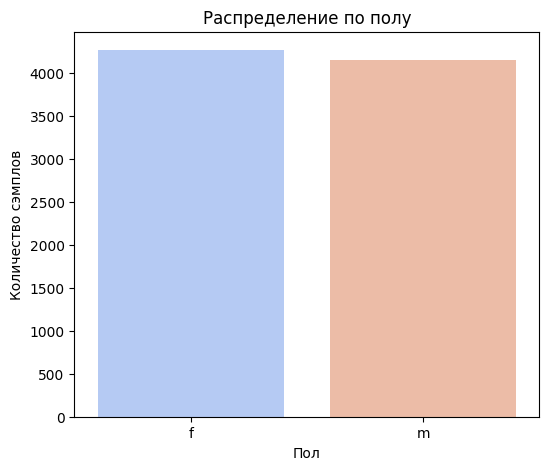

In [7]:
# Блок 6: Баланс пола
gender_counts = df['gender'].value_counts()
print("Распределение по полу:\n", gender_counts)

plt.figure(figsize=(6,5))
sns.barplot(x=gender_counts.index, y=gender_counts.values,
            hue=gender_counts.index, palette='coolwarm', legend=False)
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество сэмплов')
plt.show()

2.3.2. Примеры типичных изображений

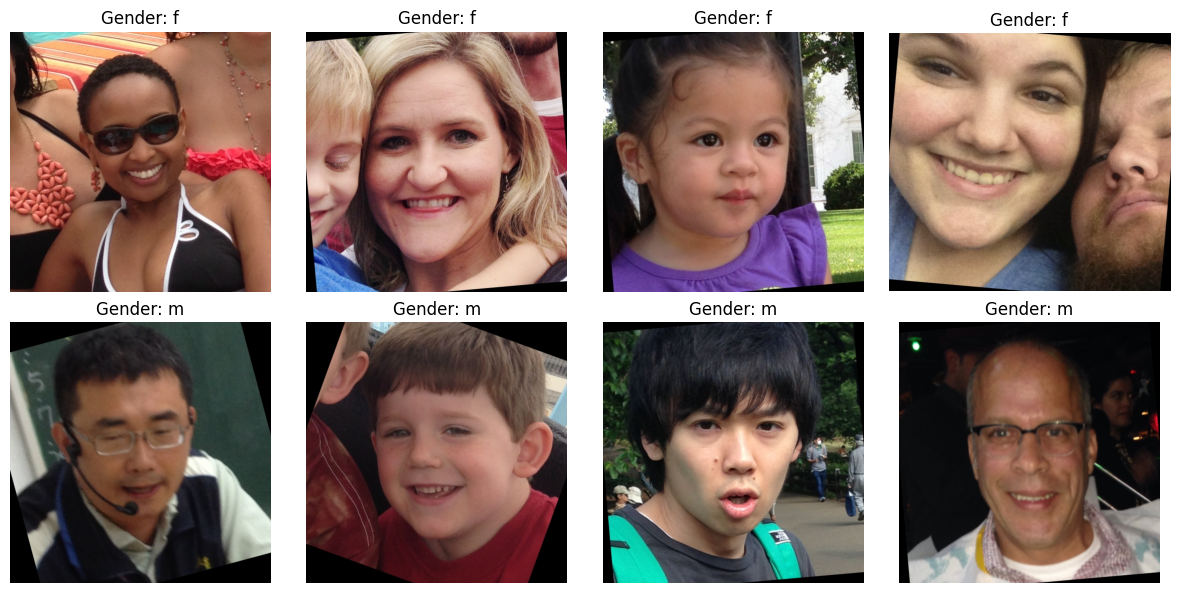

In [17]:
# 2.3.2. Примеры типичных изображений (улучшенный вариант)

genders = ['f', 'm']
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, g in enumerate(genders):
    subset = df[(df['gender'] == g) & df['file_path'].notna()]

    samples = subset.sample(4, random_state=42).reset_index()

    for j, row in samples.iterrows():
        try:
            img = Image.open(row['file_path'])
            axes[i, j].imshow(img)

            # теперь всё точно соответствует
            axes[i, j].set_title(
                f'Gender: {row["gender"]}'
            )

        except:
            axes[i, j].set_title('Ошибка')

        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

2.3.3. Оценка качества изображений

Проверено файлов: 8417
Мин. размер: 512x512
Макс. размер: 800x932
Средний размер: 594x600


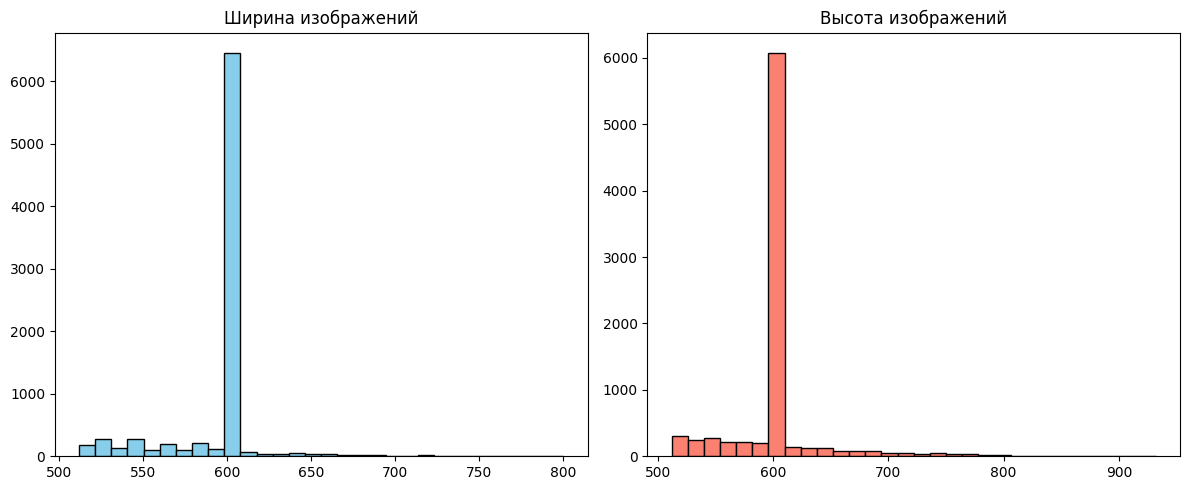

In [18]:
# Блок 2.3.3: Размеры изображений (все >= 512x512)
unique_files = df['file_path'].dropna().unique()
widths, heights = [], []
for fpath in unique_files:
    with Image.open(fpath) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)

widths = np.array(widths)
heights = np.array(heights)
print(f"Проверено файлов: {len(widths)}")
print(f"Мин. размер: {widths.min()}x{heights.min()}")
print(f"Макс. размер: {widths.max()}x{heights.max()}")
print(f"Средний размер: {widths.mean():.0f}x{heights.mean():.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.hist(widths, bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Ширина изображений')
ax2.hist(heights, bins=30, color='salmon', edgecolor='black')
ax2.set_title('Высота изображений')
plt.tight_layout()
plt.show()

2.3.4. Анализ аннотаций

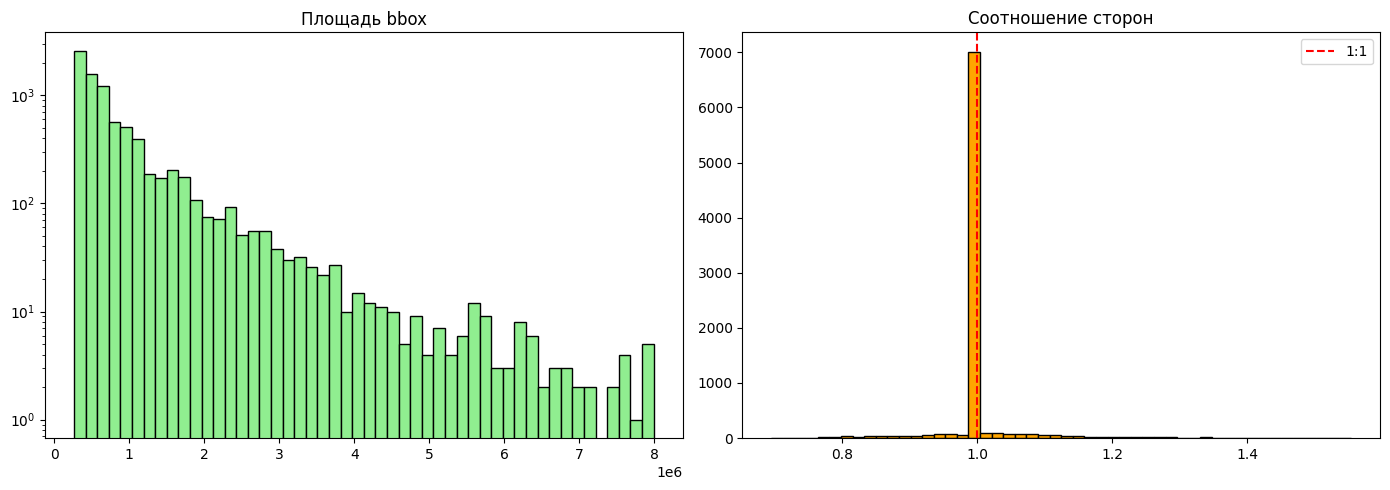

Средняя площадь: 886814 px²
Медианное соотношение сторон: 1.000


In [19]:
# Блок 2.3.4: Характеристики bbox
df['area'] = df['dx'] * df['dy']
df['aspect_ratio'] = df['dx'] / df['dy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.hist(df['area'], bins=50, color='lightgreen', edgecolor='black', log=True)
ax1.set_title('Площадь bbox')
ax2.hist(df['aspect_ratio'], bins=50, color='orange', edgecolor='black')
ax2.set_title('Соотношение сторон')
ax2.axvline(1.0, color='red', linestyle='--', label='1:1')
ax2.legend()
plt.tight_layout()
plt.show()

print(f"Средняя площадь: {df['area'].mean():.0f} px²")
print(f"Медианное соотношение сторон: {df['aspect_ratio'].median():.3f}")

2.3.5. Оценка качества разметки

Уникальные значения пола:
['f' 'm']

Пропуски в столбцах:
gender            0
original_image    0
file_path         0
dtype: int64

Изображений с несколькими лицами: 1327 из 6825 (19.4%)


/tmp/ipykernel_9870/123822920.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_distribution.index, y=count_distribution.values, palette='Purples_r')


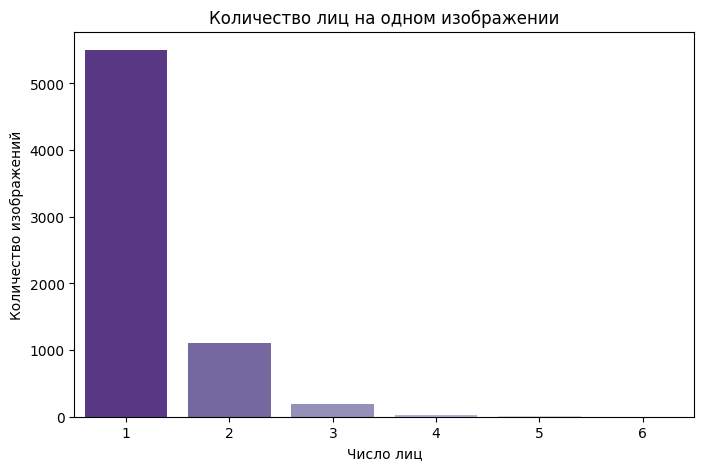

In [20]:
# Блок 2.3.5: Качество разметки
print("Уникальные значения пола:")
print(df['gender'].unique())
print("\nПропуски в столбцах:")
print(df[['gender', 'original_image', 'file_path']].isnull().sum())

faces_per_image = df.groupby('original_image')['face_id'].count()
multi_face = (faces_per_image > 1).sum()
total_images = df['original_image'].nunique()
print(f"\nИзображений с несколькими лицами: {multi_face} из {total_images} ({100*multi_face/total_images:.1f}%)")

plt.figure(figsize=(8,5))
count_distribution = faces_per_image.value_counts().sort_index()
sns.barplot(x=count_distribution.index, y=count_distribution.values, palette='Purples_r')
plt.title('Количество лиц на одном изображении')
plt.xlabel('Число лиц')
plt.ylabel('Количество изображений')
plt.show()

# 2.3.6 Разнообразие данных (ракурсы лиц)

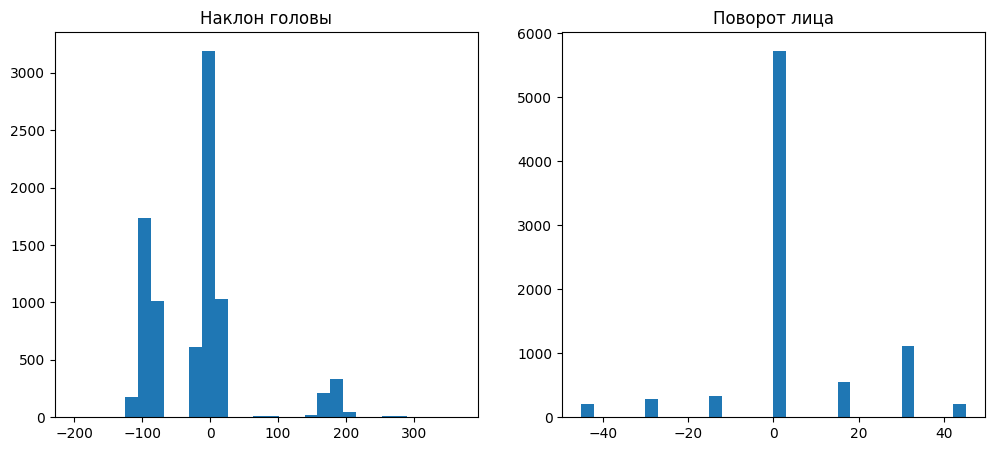

In [21]:
# 2.3.6 Разнообразие данных (ракурсы лиц)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['tilt_ang'], bins=30)
plt.title('Наклон головы')

plt.subplot(1,2,2)
plt.hist(df['fiducial_yaw_angle'], bins=30)
plt.title('Поворот лица')

plt.show()

# 2.3.7 Возрастное распределение

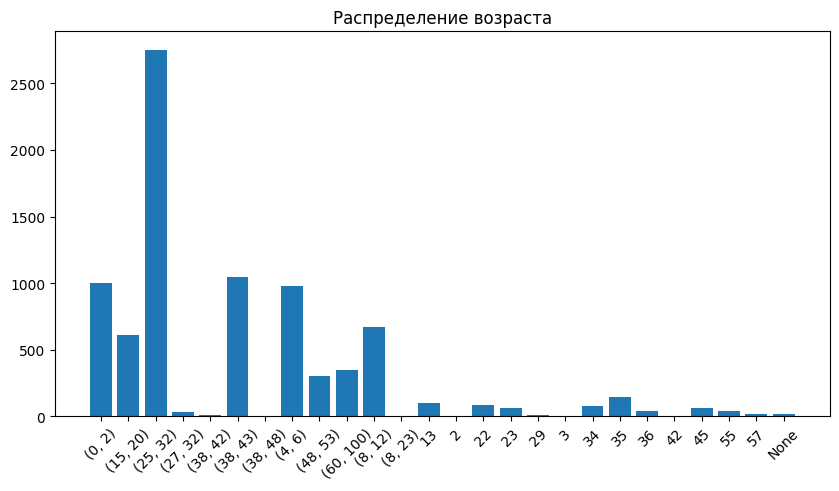

In [16]:
# 2.3.7 Возрастное распределение

age_counts = df['age'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.xticks(rotation=45)
plt.title('Распределение возраста')
plt.show()

4.2. Структура каталогов для классификации пола

In [22]:
# Блок 4.2: Создание структуры каталогов и копирование файлов
base_dir = "/content/gender_classification"
splits = ['train', 'val', 'test']
genders = ['f', 'm']

for split in splits:
    for g in genders:
        os.makedirs(os.path.join(base_dir, split, g), exist_ok=True)

# Разбиение по оригинальным изображениям
unique_images = df['original_image'].unique()
train_imgs, testval_imgs = train_test_split(unique_images, test_size=0.3, random_state=42)
val_imgs, test_imgs = train_test_split(testval_imgs, test_size=0.5, random_state=42)
img_to_split = {}
img_to_split.update({img: 'train' for img in train_imgs})
img_to_split.update({img: 'val' for img in val_imgs})
img_to_split.update({img: 'test' for img in test_imgs})

df['split'] = df['original_image'].map(img_to_split)

# Копирование
count = 0
start = time.time()
for _, row in df.iterrows():
    src = row['file_path']
    gender = row['gender']
    split = row['split']
    dst_dir = os.path.join(base_dir, split, gender)
    dst_file = os.path.join(dst_dir, os.path.basename(src))
    if not os.path.exists(dst_file):
        shutil.copy2(src, dst_file)
    count += 1
    if count % 500 == 0:
        print(f"Скопировано {count} из {len(df)} за {time.time()-start:.1f} сек")

print(f"Готово! Всего скопировано {count} файлов.")

!apt-get install -qq tree > /dev/null
print("\nФинальная структура:\n")
!tree -d /content/gender_classification

Скопировано 500 из 8417 за 0.6 сек
Скопировано 1000 из 8417 за 1.2 сек
Скопировано 1500 из 8417 за 1.7 сек
Скопировано 2000 из 8417 за 2.4 сек
Скопировано 2500 из 8417 за 3.2 сек
Скопировано 3000 из 8417 за 3.8 сек
Скопировано 3500 из 8417 за 4.5 сек
Скопировано 4000 из 8417 за 5.3 сек
Скопировано 4500 из 8417 за 6.2 сек
Скопировано 5000 из 8417 за 7.0 сек
Скопировано 5500 из 8417 за 7.6 сек
Скопировано 6000 из 8417 за 8.2 сек
Скопировано 6500 из 8417 за 8.8 сек
Скопировано 7000 из 8417 за 9.5 сек
Скопировано 7500 из 8417 за 10.1 сек
Скопировано 8000 из 8417 за 10.9 сек
Готово! Всего скопировано 8417 файлов.

Финальная структура:

/content/gender_classification
├── test
│   ├── f
│   └── m
├── train
│   ├── f
│   └── m
└── val
    ├── f
    └── m

9 directories


In [ ]:
# Блок скачивания
!zip -r /content/gender_classification.zip /content/gender_classification
from google.colab import files
files.download('/content/gender_classification.zip')

4.3. Метаданные

In [ ]:
# Блок 4.3: Экспорт метаданных
metadata = df[['file_path', 'gender', 'x', 'y', 'dx', 'dy', 'tilt_ang', 'fiducial_yaw_angle']].copy()
metadata.to_csv('adience_gender_metadata.csv', index=False)
print("Метаданные сохранены в adience_gender_metadata.csv")
print(f"Записей: {len(metadata)}")

print("\nИнформация о версии датасета:")
print("Дата скачивания: 23.04.2026")
print("Источник: https://www.kaggle.com/datasets/ttungl/adience-benchmark-gender-and-age-classification")
print("Версия Kaggle: 1 (по умолчанию)")